Project: Statistical Analysis of Student Performance
What this project demonstrates
Mean, median, variance

Standard deviation

Quartiles and IQR

Outlier detection

Histogram

Box plot

Scatter plot

Correlation

Z-test

One-sample t-test

Two-sample t-test

Chi-square test

One-way ANOVA

p-value interpretation

Statistical conclusions



In [26]:
# STATISTICAL ANALYSIS OF STUDENT PERFORMANCE
print("STATISTICAL ANALYSIS OF STUDENT PERFORMANCE")
print("=" * 55)
print("Using Python, Pandas, NumPy, SciPy and Matplotlib")

STATISTICAL ANALYSIS OF STUDENT PERFORMANCE
Using Python, Pandas, NumPy, SciPy and Matplotlib


Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    ttest_1samp,
    ttest_ind,
    chi2_contingency,
    f_oneway,
    norm
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

Create Dataset

In [3]:
np.random.seed(42)

n = 100

data = {
    "Student_ID": range(1, n + 1),
    "Study_Hours": np.round(np.random.normal(5, 1.5, n), 1),
    "Attendance": np.round(np.random.normal(80, 8, n), 1),
    "Math_Score": np.round(np.random.normal(72, 12, n), 1),
    "Science_Score": np.round(np.random.normal(74, 10, n), 1),
    "English_Score": np.round(np.random.normal(76, 9, n), 1),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Result": np.random.choice(["Pass", "Fail"], n, p=[0.8, 0.2]),
    "Study_Group": np.random.choice(
        ["Low", "Medium", "High"], n, p=[0.3, 0.4, 0.3]
    )
}

df = pd.DataFrame(data)

# Keep values within realistic limits
df["Study_Hours"] = df["Study_Hours"].clip(0, 10)
df["Attendance"] = df["Attendance"].clip(40, 100)

df["Math_Score"] = df["Math_Score"].clip(0, 100)
df["Science_Score"] = df["Science_Score"].clip(0, 100)
df["English_Score"] = df["English_Score"].clip(0, 100)

df.head()

,Student_ID,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Gender,Result,Study_Group
0,1,5.7,68.7,76.3,65.7,61.7,Female,Pass,Medium
1,2,4.8,76.6,78.7,68.4,70.6,Female,Pass,Low
2,3,6.0,77.3,85.0,81.5,76.0,Female,Pass,High
3,4,7.3,73.6,84.6,80.1,76.4,Male,Pass,High
4,5,4.6,78.7,55.5,73.8,71.9,Female,Pass,Low


In [4]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (100, 9)

Column names:
['Student_ID', 'Study_Hours', 'Attendance', 'Math_Score', 'Science_Score', 'English_Score', 'Gender', 'Result', 'Study_Group']

Data types:
Student_ID         int64
Study_Hours      float64
Attendance       float64
Math_Score       float64
Science_Score    float64
English_Score    float64
Gender            object
Result            object
Study_Group       object
dtype: object

Missing values:
Student_ID       0
Study_Hours      0
Attendance       0
Math_Score       0
Science_Score    0
English_Score    0
Gender           0
Result           0
Study_Group      0
dtype: int64


In [5]:
df.describe()

,Student_ID,Study_Hours,Attendance,Math_Score,Science_Score,English_Score
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,50.500000,4.841000,80.16200,72.599000,75.066000,75.458000
std,29.011492,1.361008,7.58194,12.486409,8.842531,9.465356
min,1.000000,1.100000,64.60000,33.100000,52.800000,55.300000
25%,25.750000,4.100000,73.57500,64.175000,68.350000,67.950000
50%,50.500000,4.800000,80.65000,73.200000,74.500000,75.300000
75%,75.250000,5.625000,84.32500,80.425000,80.825000,81.850000
max,100.000000,7.800000,100.00000,100.000000,95.900000,100.000000


In [6]:
math_scores = df["Math_Score"]

print("Mean:", math_scores.mean())
print("Median:", math_scores.median())
print("Variance:", math_scores.var())
print("Standard Deviation:", math_scores.std())
print("Minimum:", math_scores.min())
print("Maximum:", math_scores.max())



Mean: 72.599
Median: 73.2
Variance: 155.91040303030306
Standard Deviation: 12.486408732309826
Minimum: 33.1
Maximum: 100.0


Box Plot and Outlier Detection

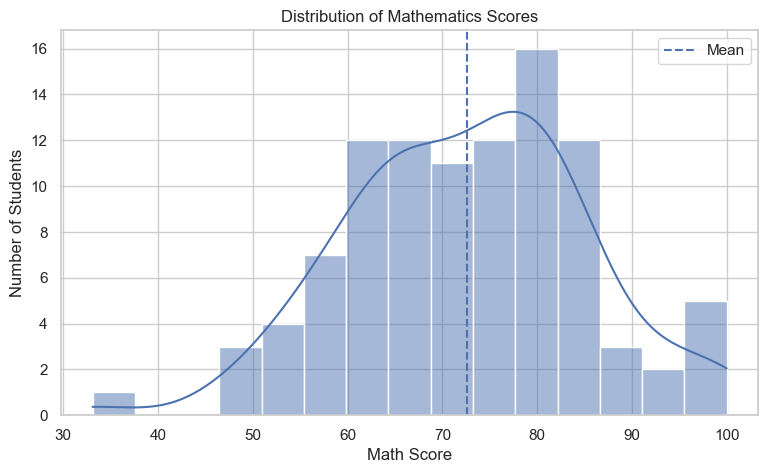

In [7]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["Math_Score"],
    bins=15,
    kde=True
)

plt.axvline(
    df["Math_Score"].mean(),
    linestyle="--",
    label="Mean"
)

plt.title("Distribution of Mathematics Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()

plt.show()

Compare Subject Scores

In [9]:
Q1 = df["Math_Score"].quantile(0.25)
Q3 = df["Math_Score"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Math_Score"] < lower_bound) |
    (df["Math_Score"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Outliers:", len(outliers))

print("\nOutlier Students:")
print(outliers[["Student_ID", "Math_Score"]])

Q1: 64.175
Q3: 80.425
IQR: 16.25
Lower Bound: 39.8
Upper Bound: 104.8

Number of Outliers: 1

Outlier Students:
    Student_ID  Math_Score
62          63        33.1


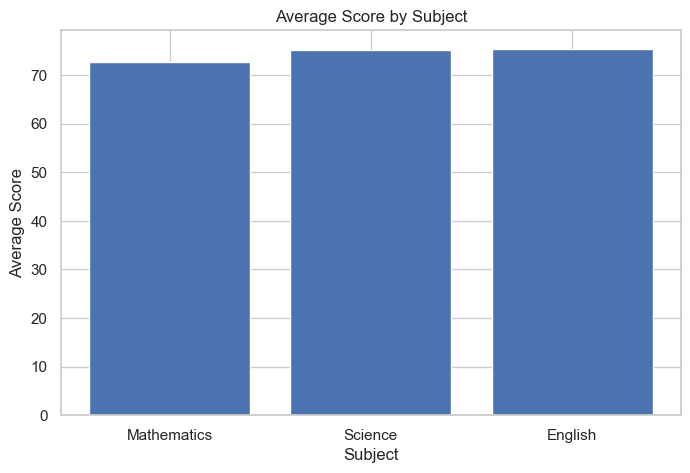

In [10]:
subject_means = {
    "Mathematics": df["Math_Score"].mean(),
    "Science": df["Science_Score"].mean(),
    "English": df["English_Score"].mean()
}

plt.figure(figsize=(8, 5))

plt.bar(
    subject_means.keys(),
    subject_means.values()
)

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")

plt.show()

Correlation Analysis

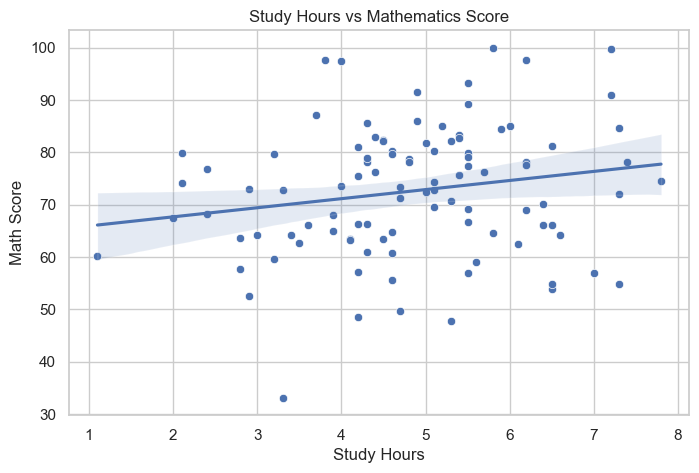

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Math_Score"
)

sns.regplot(
    data=df,
    x="Study_Hours",
    y="Math_Score",
    scatter=False
)

plt.title("Study Hours vs Mathematics Score")
plt.xlabel("Study Hours")
plt.ylabel("Math Score")

plt.show()

In [12]:
correlation = df["Study_Hours"].corr(df["Math_Score"])

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.18935513475790225


 Correlation Matrix

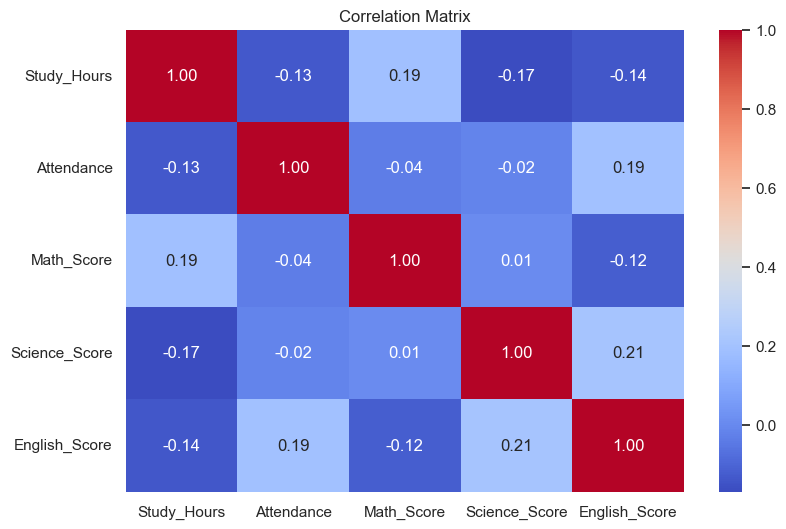

In [13]:
numeric_columns = [
    "Study_Hours",
    "Attendance",
    "Math_Score",
    "Science_Score",
    "English_Score"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

One-Sample T-Test

In [14]:
sample_mean = df["Math_Score"].mean()

t_stat, p_value = ttest_1samp(
    df["Math_Score"],
    70
)

print("Sample Mean:", sample_mean)
print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nConclusion:")
    print("Reject H0.")
    print("The average Math score is significantly different from 70.")
else:
    print("\nConclusion:")
    print("Fail to reject H0.")
    print("There is not enough evidence that the average differs from 70.")

Sample Mean: 72.599
T-statistic: 2.0814631778590047
P-value: 0.039971791828815044

Conclusion:
Reject H0.
The average Math score is significantly different from 70.


Two-Sample T-Test

In [15]:
male_scores = df[
    df["Gender"] == "Male"
]["Math_Score"]

female_scores = df[
    df["Gender"] == "Female"
]["Math_Score"]

t_stat, p_value = ttest_ind(
    male_scores,
    female_scores,
    equal_var=False
)

print("Male Mean:", male_scores.mean())
print("Female Mean:", female_scores.mean())

print("\nT-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nSignificant difference exists between the two groups.")
else:
    print("\nNo statistically significant difference was detected.")

Male Mean: 73.69772727272726
Female Mean: 71.73571428571428

T-statistic: 0.7707740037077445
P-value: 0.4428899320241737

No statistically significant difference was detected.


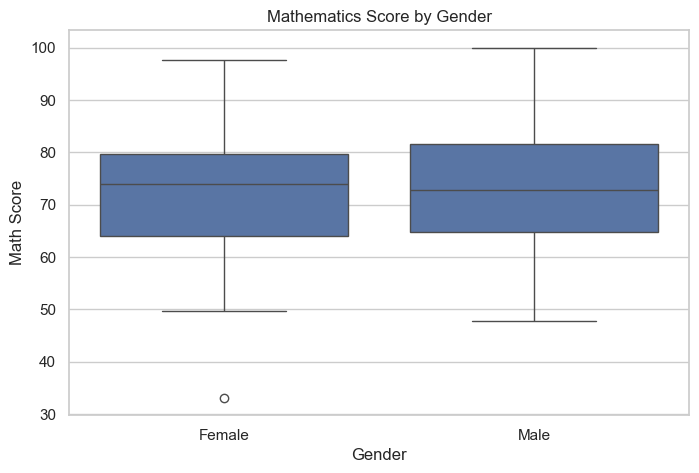

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Math_Score"
)

plt.title("Mathematics Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")

plt.show()

Chi-Square Test

In [17]:
contingency_table = pd.crosstab(
    df["Gender"],
    df["Result"]
)

print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nConclusion:")
    print("There is a statistically significant association.")
else:
    print("\nConclusion:")
    print("No statistically significant association was detected.")

Result  Fail  Pass
Gender            
Female    12    44
Male      10    34

Chi-square statistic: 0.0
Degrees of freedom: 1
P-value: 1.0

Conclusion:
No statistically significant association was detected.


One-Way ANOVA

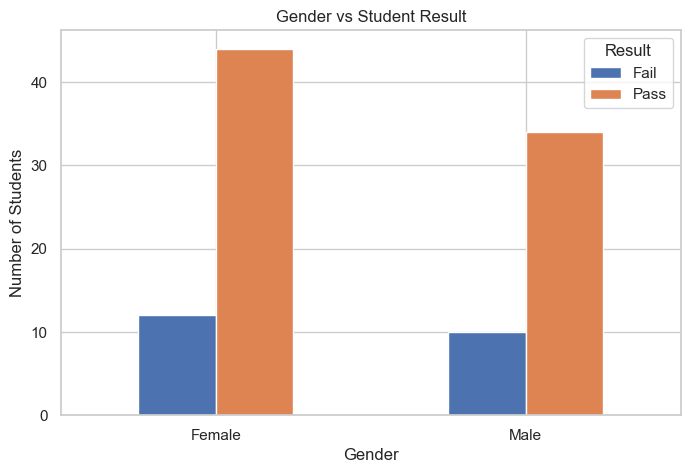

In [18]:
contingency_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Gender vs Student Result")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.legend(title="Result")

plt.show()

In [19]:
low = df[
    df["Study_Group"] == "Low"
]["Math_Score"]

medium = df[
    df["Study_Group"] == "Medium"
]["Math_Score"]

high = df[
    df["Study_Group"] == "High"
]["Math_Score"]

f_stat, p_value = f_oneway(
    low,
    medium,
    high
)

print("Low Study Group Mean:", low.mean())
print("Medium Study Group Mean:", medium.mean())
print("High Study Group Mean:", high.mean())

print("\nF-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nConclusion:")
    print("At least one group has a significantly different mean.")
else:
    print("\nConclusion:")
    print("No statistically significant difference was detected.")

Low Study Group Mean: 73.16842105263159
Medium Study Group Mean: 69.34615384615384
High Study Group Mean: 77.17391304347827

F-statistic: 3.0256378514673457
P-value: 0.0531300898013492

Conclusion:
No statistically significant difference was detected.


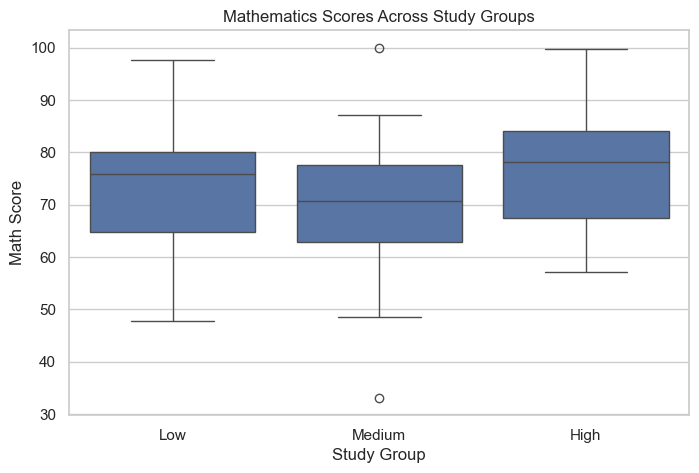

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Study_Group",
    y="Math_Score",
    order=["Low", "Medium", "High"]
)

plt.title("Mathematics Scores Across Study Groups")
plt.xlabel("Study Group")
plt.ylabel("Math Score")

plt.show()

Z-test

In [21]:
sample = df["Math_Score"]

sample_mean = sample.mean()
population_mean = 70
population_std = sample.std(ddof=0)
sample_size = len(sample)

z_score = (
    sample_mean - population_mean
) / (
    population_std / np.sqrt(sample_size)
)

p_value = 2 * (1 - norm.cdf(abs(z_score)))

print("Sample Mean:", sample_mean)
print("Z-score:", z_score)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nConclusion:")
    print("Reject H0.")
else:
    print("\nConclusion:")
    print("Fail to reject H0.")

Sample Mean: 72.599
Z-score: 2.091949204817911
P-value: 0.03644305980552809

Conclusion:
Reject H0.


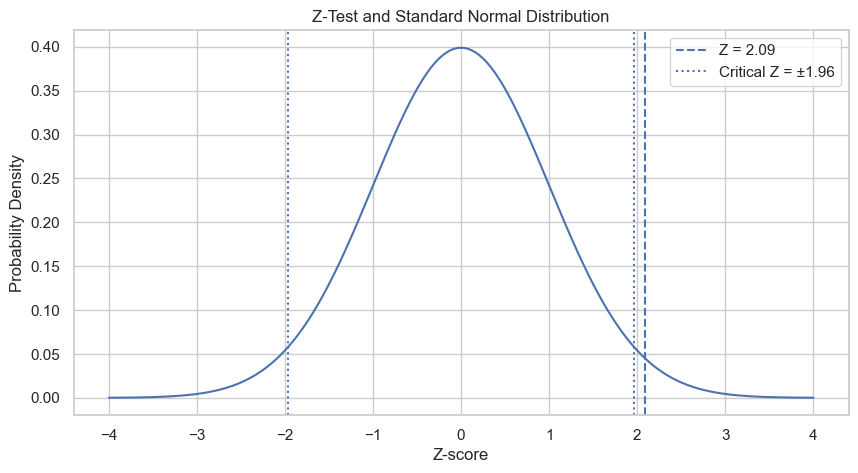

In [22]:
x = np.linspace(-4, 4, 500)
y = norm.pdf(x)

plt.figure(figsize=(10, 5))

plt.plot(x, y)

plt.axvline(
    z_score,
    linestyle="--",
    label=f"Z = {z_score:.2f}"
)

plt.axvline(
    1.96,
    linestyle=":",
    label="Critical Z = ±1.96"
)

plt.axvline(-1.96, linestyle=":")

plt.title("Z-Test and Standard Normal Distribution")
plt.xlabel("Z-score")
plt.ylabel("Probability Density")

plt.legend()

plt.show()

Statistical Summary

In [24]:
t1_stat, t1_p = ttest_1samp(df["Math_Score"], 70)

t2_stat, t2_p = ttest_ind(
    male_scores,
    female_scores,
    equal_var=False
)

chi_stat, chi_p, _, _ = chi2_contingency(contingency_table)

anova_stat, anova_p = f_oneway(
    low,
    medium,
    high
)

z_p = 2 * (1 - norm.cdf(abs(z_score)))

summary = pd.DataFrame({
    "Test": [
        "One-Sample T-Test",
        "Two-Sample T-Test",
        "Chi-Square Test",
        "One-Way ANOVA",
        "Z-Test"
    ],
    "Statistic": [
        t1_stat,
        t2_stat,
        chi_stat,
        anova_stat,
        z_score
    ],
    "P_Value": [
        t1_p,
        t2_p,
        chi_p,
        anova_p,
        z_p
    ]
})

summary["Result"] = np.where(
    summary["P_Value"] < 0.05,
    "Statistically Significant",
    "Not Statistically Significant"
)

summary

,Test,Statistic,P_Value,Result
0,One-Sample T-Test,2.081463,0.039972,Statistically Significant
1,Two-Sample T-Test,0.770774,0.442890,Not Statistically Significant
2,Chi-Square Test,0.000000,1.000000,Not Statistically Significant
3,One-Way ANOVA,3.025638,0.053130,Not Statistically Significant
4,Z-Test,2.091949,0.036443,Statistically Significant


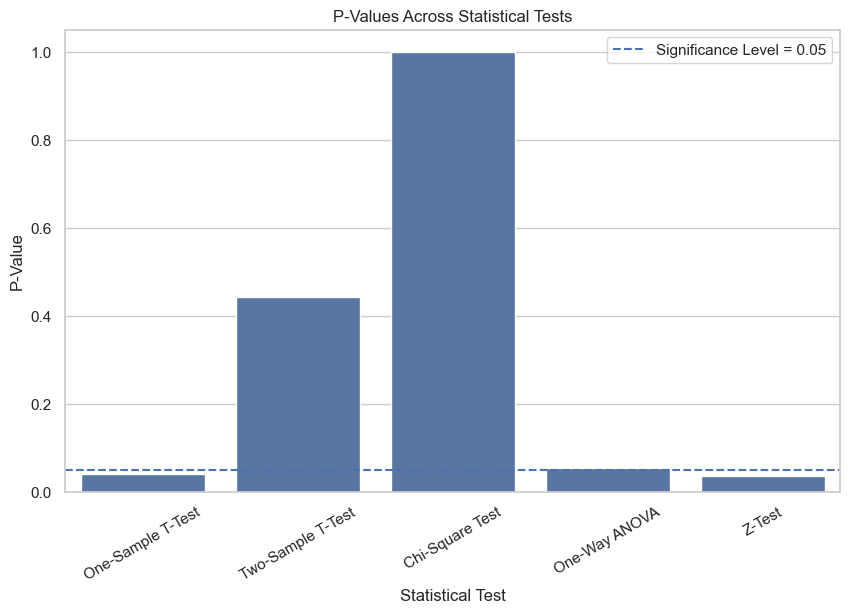

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary,
    x="Test",
    y="P_Value"
)

plt.axhline(
    0.05,
    linestyle="--",
    label="Significance Level = 0.05"
)

plt.title("P-Values Across Statistical Tests")
plt.xlabel("Statistical Test")
plt.ylabel("P-Value")

plt.xticks(rotation=30)
plt.legend()

plt.show()

Conclusion

This project explored the application of statistical methods to student performance data.

The analysis covered:

- Descriptive statistics
- Data distributions
- Outlier detection using the IQR method
- Correlation analysis
- One-sample t-test
- Independent two-sample t-test
- Chi-square test
- One-way ANOVA
- Z-test
- Statistical significance using p-values

The main objective was not only to calculate statistical values, but also to understand how statistical tests can be used to answer real-world questions about data.

This project strengthened my understanding of statistics as a foundation for Machine Learning and Data Science.